In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/day2_cleaned_data.csv")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,missing_customer_flag,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


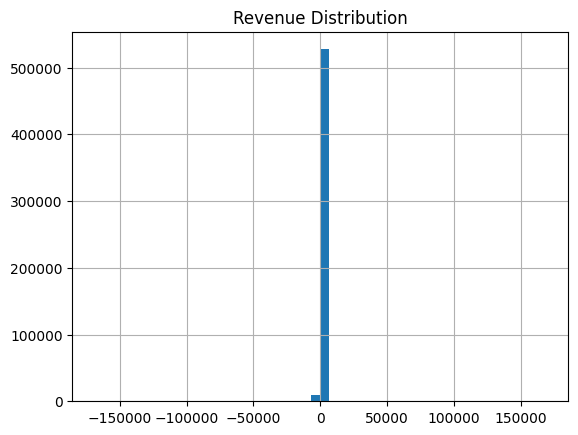

In [3]:
plt.figure()
df['Revenue'].hist(bins=50)
plt.title("Revenue Distribution")
plt.show()

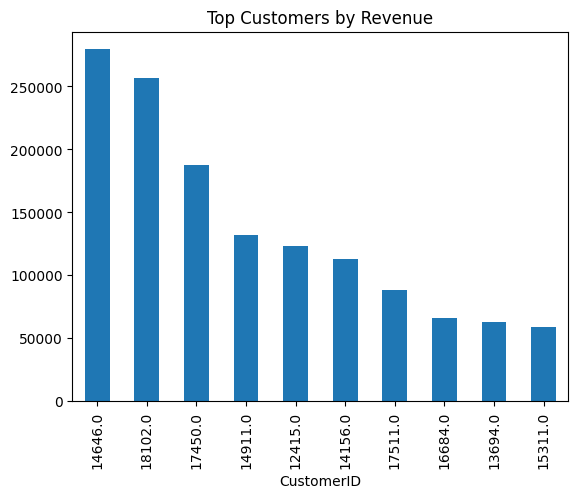

In [4]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers by Revenue")
plt.show()

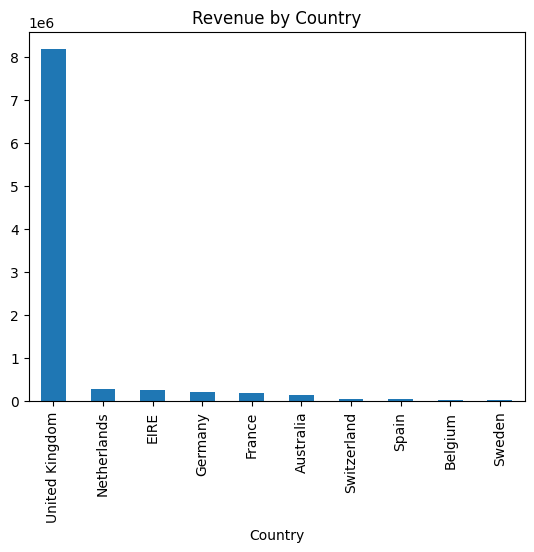

In [5]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_rev.head(10).plot(kind='bar')
plt.title("Revenue by Country")
plt.show()

In [9]:
df['is_return'] = df['Quantity'] < 0

In [7]:
df['zero_price_flag'] = df['UnitPrice'] <= 0

In [10]:
df[['missing_customer_flag', 'zero_price_flag', 'is_return']].sum()

missing_customer_flag    135037
zero_price_flag            2512
is_return                 10587
dtype: int64

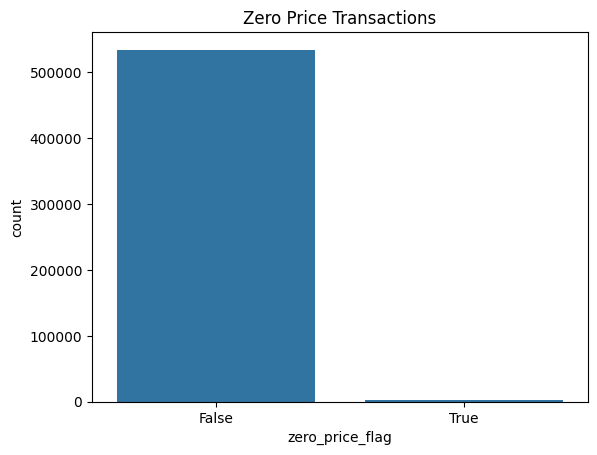

In [11]:
sns.countplot(x='zero_price_flag', data=df)
plt.title("Zero Price Transactions")
plt.show()

In [12]:
high_value = df[df['Revenue'] > df['Revenue'].quantile(0.99)]

high_value.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,missing_customer_flag,Revenue,zero_price_flag,is_return
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,False,204.00,False,False
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,False,350.40,False,False
178,536387,79321,CHILLI LIGHTS,192,2010-12-01 09:58:00,3.82,16029.0,United Kingdom,False,733.44,False,False
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,False,647.04,False,False
180,536387,22779,WOODEN OWLS LIGHT GARLAND,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,False,647.04,False,False


In [13]:
df.to_csv("../data/processed/day3_featured_data.csv", index=False)

## 📌 Day 3 Insights

- Revenue distribution is highly skewed, indicating presence of high-value transactions.
- A small number of customers contribute significantly to total revenue.
- Certain countries dominate revenue generation, indicating geographic concentration risk.
- Presence of zero-price and missing-customer transactions highlights potential audit concerns.
- High-value transactions (top 1%) identified as priority for audit review.
